## 1) Importar bibliotecas

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import PredictionErrorDisplay
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt

import polars as pl

## 2) Ler base de dados

In [2]:
data = pl.read_parquet(
    source = "./diabetes_dataset.parquet"
)

print(data.shape)
data.head(2)

(442, 11)


age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
i8,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32
59,2,32.099998,101.0,157.0,93.199997,38.0,4.0,4.8598,87.0,151.0
48,1,21.6,87.0,183.0,103.199997,70.0,3.0,3.8918,69.0,75.0


## 3) Treinamento do modelo

### 3.1) Separar por `train_test_split`:

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop("target"),
    data["target"],
    random_state = 1,
    train_size = 0.7,
)

for array in [X_train, X_test, y_train, y_test]:
    print(array.shape)

(309, 10)
(133, 10)
(309,)
(133,)


### 3.2) Treinar modelo:

In [4]:
model = LinearRegression()

model.fit(
    X = X_train,
    y = y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 3.3) Avaliar modelo:

Modelos de Regressão Linear podem ser avaliados com uma nova métrica da biblioteca `sklearn` chamado `PredictionErrorDisplay`.

Basicamente, ele avalia se o modelo linear está errando acima ou abaixo do esperado.

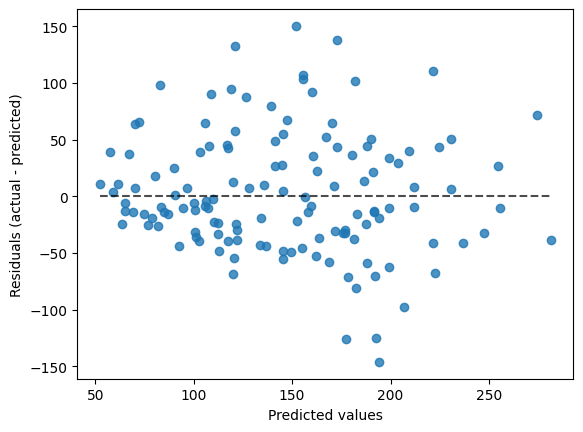

In [9]:
display = PredictionErrorDisplay(
    y_true = y_test,
    y_pred = model.predict(
        X = X_test
    )
)

display.plot()
plt.show()